In [26]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
import deepRD.tools.trajectoryTools as trajectoryTools
import csv
import math
from torchvision.transforms import ToTensor
from torch import nn
from torch.utils.data import DataLoader
from sklearn.neighbors import KernelDensity
from scipy.stats import wasserstein_distance_nd


In [27]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [28]:
class cvaeSampler(nn.Module):

    """
    Model for sampling of the interaction noise term in reduced simulations. 
    The model is a Conditional Variational Autoencoder (CVAE) architecture.

    Parameters:
    latentDims (int): dimensionality of latent (encoded) space
    loadPretrained (str): filepath of pre-trained model to be loaded
    conditionedOn (str): ['piri', 'pipimri', etc.] - set of the variables used for conditioning of the decoding/encoding
    systemType (str): ['bistable', 'dimer'] 
    hidden_dims (1-D array of int): e.g. [128, 64, 32] ; determines the encoder/decoder structure given as subsequent hidden layers
    
    norm_params: mean and std of input and conditional distributions, for normalization/denormalization
    """

    def __init__(self, latentDims, loadPretrained, conditionedOn, systemType, hidden_dims=None, batch_norm=False, 
                 dropout_rate=0, norm_params=(0,1,0,1)):
        
        super().__init__()
        self.conditionedOn = conditionedOn
        self.systemType = systemType
        self.latentDims = latentDims
        self.loadPretrained = loadPretrained
        self.conditionDims = self.getConditionDims()
        self.inputDims = self.getInputDims()
        self.G = torch.distributions.Normal(0, 1)

        if hidden_dims==None:
            # Initialising template network architecture
            fhl = 20

            self.encoder = nn.Sequential(
                nn.Linear(self.inputDims+self.conditionDims, 128),
                nn.ReLU(),
                nn.Linear(128, 64),
                nn.ReLU(),
                nn.Linear(64, 40),
                nn.ReLU(),
                nn.Linear(40, 20),
                nn.ReLU()
            )
            
            self.decoder = nn.Sequential(
                nn.Linear(self.latentDims+self.conditionDims, 20),
                nn.ReLU(),
                nn.Linear(20, 40),
                nn.ReLU(),
                nn.Linear(40, 64),
                nn.ReLU(),
                nn.Linear(64, 128),
                nn.ReLU(),
                nn.Linear(128, self.inputDims)
            )

        else:
            # Building custom network architecture

            fhl = hidden_dims[-1]

            if dropout_rate>0 and batch_norm==True:
                print('Use either BN or Dropout.')

            elif batch_norm: # Using Batch Norm only 
                self.encoder = nn.Sequential(
                nn.Linear(self.inputDims+self.conditionDims, hidden_dims[0]),
                nn.BatchNorm1d(hidden_dims[0]),
                nn.ReLU()
                )

                self.decoder = nn.Sequential(
                nn.Linear(self.latentDims+self.conditionDims, hidden_dims[-1]),
                nn.BatchNorm1d(hidden_dims[-1]),
                nn.ReLU()
                )

            else: # No BN
                
                self.encoder = nn.Sequential(
                nn.Linear(self.inputDims+self.conditionDims, hidden_dims[0]),
                nn.ReLU()
                )   

                self.decoder = nn.Sequential(
                nn.Linear(self.latentDims+self.conditionDims, hidden_dims[-1]),
                nn.ReLU()
                )

            for i in range(1, len(hidden_dims)):

                if dropout_rate>0:
                    self.encoder.append(nn.Dropout(dropout_rate))
                self.encoder.append(nn.Linear(hidden_dims[i-1], hidden_dims[i]))
                if batch_norm:
                    self.encoder.append(nn.BatchNorm1d(hidden_dims[i]))
                self.encoder.append(nn.ReLU())


                if dropout_rate>0:
                    self.decoder.append(nn.Dropout(dropout_rate))
                self.decoder.append(nn.Linear(hidden_dims[-i], hidden_dims[-(i+1)]))
                if batch_norm:
                    self.decoder.append(nn.BatchNorm1d(hidden_dims[-(i+1)]))
                self.decoder.append(nn.ReLU())

            self.decoder.append(nn.Linear(hidden_dims[0], self.inputDims))

        self.linear1 = nn.Linear(fhl, self.latentDims)
        self.linear2 = nn.Linear(fhl, self.latentDims)
        self.load_model()
        
        self.mean_inp, self.std_inp, self.mean_cond, self.std_cond = norm_params


    def load_model(self):
        if self.loadPretrained==None:
            print('Untrained model initialized. Conditioned on:', self.conditionedOn)
        else:
            print('Loading pretrained model: ' + self.loadPretrained)
            self.load_state_dict(torch.load(self.loadPretrained))
            print('Model parameters loaded.')

    def reparametrize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        return mu + std*self.G.sample(mu.shape).to(device)
    
    def normalize(self, x, mean, std):
        
        """
        Normalizes a tensor w.r.t a given mean and std.
        """
        return (x-mean.to(device))/std.to(device)

    def denormalize(self, x, mean, std):
        """
        Denormalizes a tensor w.r.t a given mean and std.
        """
        return x*std.to(device) + mean.to(device)
    
    
    def sample(self, label, num_samples=1):
        '''
         Here a slight workaround to get compatibility between model and integrator.
         Model is designed and trained to work on Torch tensors of size (num_samples, *), meanwhile 
         integrator works on 1-D arrays. 

         Returns: 1-D Torch Tensor of size (3)
        '''

        mean = 0
        std = 1
        
        # Normalizing labels for inference
        label = self.normalize(label, self.mean_cond, self.std_cond)

        if isinstance(label, np.ndarray):

            with torch.no_grad():
                label = torch.from_numpy(label).float()

                if self.systemType=='bistable':
                    # Extracting labels
                    if self.conditionedOn=="piri":
                        r = label[3:]
                        v = label[:3]
                        label = torch.cat((r,v))
                    elif self.conditionedOn=="piririm":
                        v = label[:3]
                        r = label[3:6]
                        r_prev = label[6:9]
                        label = torch.cat((v, r, r_prev))
                    elif self.conditionedOn=="pipimri":
                        v = label[:3]
                        v_prev = label[3:6]
                        r = label[6:9]
                        label = torch.cat((v, v_prev, r))

                elif self.systemType=='dimer':

                    if self.conditionedOn=="piri":
                        # ConditionedVars = (particle1.nextVelocity, particle2.nextVelocity, particle1.aux1, particle2.aux1)
                        v_1 = label[:3]
                        v_2 = label[3:6]
                        r_1 = label[6:9]
                        r_2 = label[9:12]
                        label = torch.cat((v_1, v_2, r_1, r_2))

                label = label.unsqueeze(0)
                samples = torch.normal(mean, std, (num_samples, self.latentDims))
                z_cond = torch.cat((samples, label), dim=1)
                out = np.array(self.decoder(z_cond).squeeze(0))

        else: 
            
            if label.dim()==1:
                label = label.unsqueeze(0)

            samples = torch.normal(mean, std, (num_samples, self.latentDims))
            z_cond = torch.cat((samples, label), dim=1)
            out = self.decoder(z_cond)
            
        # Denormalizing output
        out = self.denormalize(out, self.mean_inp, self.std_inp)

        return out

    def forward(self, x, y, returnLatent=False):
        
        # Preprocessing data
        x = self.normalize(x, self.mean_inp, self.std_inp)
        y = self.normalize(y, self.mean_cond, self.std_cond)
        
        # Passing through network
        x_cond = torch.cat((x,y), dim=1)
        x = self.encoder(x_cond)
        mu = self.linear1(x)
        logvar = self.linear2(x)
        z = self.reparametrize(mu, logvar)
        z_cond = torch.cat((z, y), dim=1)
        output = self.decoder(z_cond)
        
        # Denormalizing output to original form
        output = self.denormalize(output, self.mean_inp, self.std_inp)

        if returnLatent==True:
            return output, mu, logvar, z
        
        return output, mu, logvar
    
    def getConditionDims(self):

        if self.systemType=='bistable':    
            if self.conditionedOn=="piri":
                return 6
            elif self.conditionedOn=="piririm":
                return 9
            elif self.conditionedOn=="piripim":
                return 9
            elif self.conditionedOn=="piririmpim":
                return 12
            else:
                print('Unsupported model type')
                return None

        elif self.systemType=='dimer':    
            if self.conditionedOn=="piri":
                return 12
            else:
                print('Unsupported model type')
                return None

    def getInputDims(self):

        if self.systemType=='bistable':
            return 3
        elif self.systemType=='dimer':
            return 6

In [29]:
class Annealer:
    """
    This class is used to anneal the KL divergence loss over the course of training VAEs.
    After each call, the step() function should be called to update the current epoch.
    """

    def __init__(self, total_steps, shape, baseline=0.0, cyclical=False, disable=False):
        """
        Parameters:
            total_steps (int): Number of epochs to reach full KL divergence weight.
            shape (str): Shape of the annealing function. Can be 'linear', 'cosine', or 'logistic'.
            baseline (float): Starting value for the annealing function [0-1]. Default is 0.0.
            cyclical (bool): Whether to repeat the annealing cycle after total_steps is reached.
            disable (bool): If true, the __call__ method returns unchanged input (no annealing).
        """
        self.total_steps = total_steps
        self.current_step = 0
        self.cyclical = cyclical
        self.shape = shape
        self.baseline = baseline
        if disable:
            self.shape = 'none'
            self.baseline = 0.0

    def __call__(self, kld):
        """
        Args:
            kld (torch.tensor): KL divergence loss
        Returns:
            out (torch.tensor): KL divergence loss multiplied by the value (slope) of the annealing function.
        """
        out = kld * self.slope()
        return out

    def slope(self):
        if self.shape == 'linear':
            y = (self.current_step / self.total_steps)
        elif self.shape == 'cosine':
            y = (math.cos(math.pi * (self.current_step / self.total_steps - 1)) + 1) / 2
        elif self.shape == 'logistic':
            exponent = ((self.total_steps / 2) - self.current_step)
            y = 1 / (1 + math.exp(exponent))
        elif self.shape == 'none':
            y = 1.0
        else:
            raise ValueError('Invalid shape for annealing function. Must be linear, cosine, or logistic.')
        y = self.add_baseline(y)
        return y

    def step(self):
        if self.current_step < self.total_steps:
            self.current_step += 1
        if self.cyclical and self.current_step >= self.total_steps:
            self.current_step = 0
        return

    def add_baseline(self, y):
        y_out = y * (1 - self.baseline) + self.baseline
        return y_out

    def cyclical_setter(self, value):
        if value is not bool:
            raise ValueError('Cyclical_setter method requires boolean argument (True/False)')
        else:
            self.cyclical = value
        return

In [30]:
# Defining loss functions 
loss_1 = nn.MSELoss()
def loss_2(mu, logvar):
    return torch.mean(-0.5 * torch.sum(1 + logvar - mu ** 2 - torch.exp(logvar), dim = 1), dim = 0)#.sum()

In [31]:
def modelTraining(data_loader, epochs, beta1, beta2, test_data_loader):
    
    return_reconstructions = False
    losses = []
    losses_EP = []
    r_norms = None
    r_new = None

    annealing_period = 10
    annealing_agent = Annealer(annealing_period, shape='logistic', cyclical=True, disable=False) # instantiating annealing agent
    
    for epoch in range(epochs):
        VAE.train()
        r_epoch = None
        
        # Saving loss both per-batch and total (average) loss
        val_loss = 0
        total_loss = 0
        total_l1 = 0
        total_l2 = 0
        bc = 0 # counting batches to calculate per-batch error

        # At the start of epoch, evaluate validation error.
        for (image_t, label_t) in test_data_loader:
            bc += 1
            image_t, label_t = image_t.to(device), label_t.to(device)
            reconstruction_t, mu_t, logvar_t = VAE(image_t, label_t)
            val_loss += loss_1(reconstruction_t, image_t).item() # MSE loss only on validation set

        val_loss /= bc # recover average per-batch loss
        bc = 0
        
        for (image, label) in data_loader:
            bc += 1
            
            image, label = image.to(device), label.to(device)
            
            # Feed through the network
            reconstruction, mu, logvar = VAE(image, label)
            # Calculate loss function
            l1 = loss_1(reconstruction, image)
            l2 = loss_2(mu, logvar)
            l2 = annealing_agent(l2)

            #print(annealing_agent.slope(), l2.item())
            loss = beta1*l1 + beta2*l2
            losses.append([loss.item(), beta1*l1.item(), beta2*l2.item(), val_loss])
            
            total_loss += loss.item()
            total_l1 += l1.item()
            total_l2 += l2.item()
    
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()


            if return_reconstructions and epoch==epochs-1:
                with torch.no_grad():
                    if r_epoch is None:
                        r_epoch = reconstruction
                    else:
                        r_epoch = torch.cat( (r_epoch, reconstruction), dim=0)
                        
        annealing_agent.step()
        losses_EP.append([total_l1/bc, total_l2*beta2/bc, total_loss/bc, val_loss])
        print(f'E{epoch+1}, MSE: {round(losses_EP[-1][0]*1000,4)}, KLD: {round(losses_EP[-1][1]*1000,4)}, TOT: {round(losses_EP[-1][2]*1000,4)} V: {round(losses_EP[-1][3]*1000,4)}')
    return r_epoch, losses, losses_EP

In [32]:
# System type: 'bistable', 'dimer'
systemType = 'bistable'

# Conditioning variables: piri, piririm, pipimri, etc.
conditionedOn = 'piri'

# datapoint = [time (1), qi (3), vi (3), ? (1), ri(3)] -- 11 dim

# Datasets directory
localDirectory = "/group/ag_cmb/scratch/maojrs/stochasticClosure/" + systemType + "/boxsize5/benchmark/"

# Total no. of datasets
n_datasets = 40
train_split = 0.8

# Sample simulation files randomly
fnums = np.random.choice(2500, n_datasets)
print(fnums)
dataset = None

for f_num in fnums:
    try:
        ds = torch.Tensor(trajectoryTools.loadTrajectory(localDirectory + "simMoriZwanzig_", f_num)).unsqueeze(0)
    except FileNotFoundError:
        print(f'File {f_num} not available.')
        continue
              
    if dataset is None:
        dataset = ds
    else:
        dataset = torch.cat((dataset, ds), dim=0)

# Dataset - training data
dataset.shape
#print(dataset[0, :6])

[2209 1581 2323 1257 1419 1454 1630 2381 2063  254 1178  697 2124  991
 1491  143 1764 2057 1060  766 1113 2173 1267  678   77 1064 1965 1101
  355  448  427  806  151  936  178 2248 2400   23 1405  304]


torch.Size([40, 10000, 11])

In [33]:
TT_split = 0.2 # set value for test-train split

# Number of datasets for training
n_datasets = dataset.shape[0]

if systemType=='bistable':

    # Extract desired vectors from dataset
    r_aux = dataset[:, :, -3:] 
    r_nxt = torch.roll(r_aux, -1, 1)
    r_prev = torch.roll(r_aux, 1, 1)
    v = dataset[:, :, 4:7]
    v_prev = torch.roll(v, 1, 1)

    # Cut out first & last datapoint for consistency
    r_aux = r_aux[:, 1:-1].flatten(end_dim=1)
    r_nxt = r_nxt[:, 1:-1].flatten(end_dim=1)
    r_prev = r_prev[:, 1:-1].flatten(end_dim=1)
    v = v[:, 1:-1].flatten(end_dim=1)
    v_prev = v_prev[:, 1:-1].flatten(end_dim=1)


    # Split data: first 20% test, remaining 80% test.
    split_ind = int(TT_split*len(r_aux))

    # Build labels tensor
    if conditionedOn=="piri":
        conditionalVars = torch.cat((r_aux, v), dim = 1)
    elif conditionedOn=="piririm":
        conditionalVars = torch.cat((v, r_aux, r_prev), dim = 1)
    elif conditionedOn=="pipimri":
        conditionalVars = torch.cat((v, v_prev, r_aux), dim = 1)
    else:
        print('Invalid model type.')

    inputVars = r_nxt


elif systemType=='dimer':
    # Extracting desired vectors from dataset

    r_aux1 = dataset[:, ::2, -3:] # r_n
    r_nxt1 = torch.roll(r_aux1, -1, 1) # r_n+1
    r_prev1 = torch.roll(r_aux1, 1, 1) # r_n-1
    v1 = dataset[:, ::2, 4:7] # v_n
    v_prev1 = torch.roll(v1, 1, 1) # v_n-1

    r_aux2 = dataset[:, 1::2, -3:] # r_n
    r_nxt2 = torch.roll(r_aux2, -1, 1) # r_n+1
    r_prev2 = torch.roll(r_aux2, 1, 1) # r_n-1
    v2 = dataset[:, 1::2, 4:7] # v_n
    v_prev2 = torch.roll(v2, 1, 1) # v_n-1

    # Cut out first & last datapoint for consistency
    r_aux1 = r_aux1[:, 1:-1].flatten(end_dim=1)
    r_nxt1 = r_nxt1[:, 1:-1].flatten(end_dim=1)
    r_prev1 = r_prev1[:, 1:-1].flatten(end_dim=1)
    v1 = v1[:, 1:-1].flatten(end_dim=1)
    v_prev1 = v_prev1[:, 1:-1].flatten(end_dim=1)

    r_aux2 = r_aux2[:, 1:-1].flatten(end_dim=1)
    r_nxt2 = r_nxt2[:, 1:-1].flatten(end_dim=1)
    r_prev2 = r_prev2[:, 1:-1].flatten(end_dim=1)
    v2 = v2[:, 1:-1].flatten(end_dim=1)
    v_prev2 = v_prev2[:, 1:-1].flatten(end_dim=1)


    if conditionedOn == 'piri':
        conditionalVars = torch.cat((v1, v2, r_aux1, r_aux2), dim = 1) # pi1, pi2, ri1, ri2
    else:
        print('Invalid model type')

    inputVars = torch.cat( (r_nxt1, r_nxt2), dim = 1)

    
normalize_data=False

if normalize_data:
    # Calculating mean and std of input and conditional distributions.
    mean_input, std_input = torch.mean(inputVars, dim=0), torch.std(inputVars, dim=0)
    mean_cond, std_cond = torch.mean(conditionalVars, dim=0), torch.std(conditionalVars, dim=0)
else:
    mean_input, std_input, mean_cond, std_cond = (torch.tensor(0),torch.tensor(1),torch.tensor(0),torch.tensor(1))
    
# Split data: first 20% test, remaining 80% test.
split_ind = int(TT_split*len(inputVars))

# Rebuild data for model Input: R_n+1 (3), condition: r_n, velocity_n (6)
test_data = torch.utils.data.TensorDataset(inputVars[:split_ind], conditionalVars[:split_ind])
data = torch.utils.data.TensorDataset(inputVars[split_ind:], conditionalVars[split_ind:])

inputVars.shape, conditionalVars.shape, len(test_data), len(data)

(torch.Size([399920, 3]), torch.Size([399920, 6]), 79984, 319936)

In [34]:
# Model settings

loadPretrained = None
#loadPretrained = 'modelWeights/' + 'model_state_' + conditionedOn + '_Dimer1.pt'
hiddenDims=[128,64,32]
latentDims=8

batch_norm=False
dropout_rate=0


initialize_model = True

if initialize_model:

    VAE = cvaeSampler(latentDims, loadPretrained, conditionedOn, systemType, hidden_dims=hiddenDims, 
                      batch_norm=batch_norm, dropout_rate=dropout_rate, 
                      norm_params=(mean_input, std_input, mean_cond, std_cond))
    VAE = VAE.to(device)
    
    f = open("/home/mi/jakut77/cgr/deepRD/deepRD/noiseSampler/models/modelLosses/losses_nb.csv", "w")
    f.truncate()
    f.close()
    
else:
    print('Continuing with existing model.')

# Training parameters
n_epochs = 40
batch_size = 32
# beta1 - MSE Loss, beta2 - KL Div Loss Maximum Value.
beta1 = 1 #10
beta2 = 1e-5 #5e-5#2e-5

data_loader = DataLoader(data, batch_size=batch_size, shuffle=True)
test_data_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

# Optimizer parameters:
learning_rate = 1e-4
weight_decay = 0 #1e-6 #1e-8

optimizer = torch.optim.Adam(VAE.parameters(),
                             lr = learning_rate,
                             weight_decay = weight_decay)

Untrained model initialized. Conditioned on: piri


In [ ]:
# Training data is used for fitting
_, losses, epoch_losses = modelTraining(data_loader, n_epochs, beta1, beta2, test_data_loader)

E1, MSE: 0.1597, KLD: 0.0014, TOT: 0.1611 V: 5.5282
E2, MSE: 0.0071, KLD: 0.0073, TOT: 0.0144 V: 0.0335
E3, MSE: 0.002, KLD: 0.0135, TOT: 0.0156 V: 0.0008
E4, MSE: 0.0035, KLD: 0.0217, TOT: 0.0252 V: 0.0017
E5, MSE: 0.0066, KLD: 0.0321, TOT: 0.0387 V: 0.0032
E6, MSE: 0.011, KLD: 0.037, TOT: 0.048 V: 0.0063


In [ ]:
# SAVING LOSSES
with open('modelLosses/losses_nb.csv', 'a', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerows(epoch_losses)

In [ ]:
# READING LOSS FILE
losses_sum = []
losses_1 = []
losses_2 = []
losses_val = []

#Name of loss file to read
loss_filename = 'losses_nb.csv'

with open('modelLosses/'+loss_filename, mode ='r') as file:    
       csvFile = csv.reader(file)
       for line in csvFile:
           losses_1.append(float(line[0]))
           losses_2.append(float(line[1]))
           losses_sum.append(float(line[2]))
           losses_val.append(float(line[3]))

losses_val = list(dict.fromkeys(losses_val))
len(losses_sum), len(losses_val)#, len(epoch_losses)

In [ ]:
# PLOTTING LOSS
#plt.style.use('fivethirtyeight')
plt_split = 5

fig = plt.figure(figsize=(12,4))

# Plotting the last 100 values for training loss
ax1 = fig.add_subplot(1,2,1)
ax1.plot(losses_sum[plt_split:], label='last 100')
#ax1.plot(losses_sum[:plt_split], label='first 100')
ax1.plot(losses_1[plt_split:], label='recon loss')
ax1.plot(np.array(losses_2[plt_split:]), label='KL divergence')
ax1.set_xlabel('Iterations')
ax1.set_title('Training loss')
ax1.legend()

ax2 = fig.add_subplot(1,2,2)
ax2.plot(losses_val[plt_split:], '--o')
#ax2.plot(np.array(epoch_losses[-100:])/20, label='epoch-wise loss')
ax2.set_xlabel('Epochs after first 100')
ax2.set_title('Validation loss');
print(losses_1[-1], losses_2[-1], losses_sum[-1], losses_val[-1])

In [ ]:
# Visualizing the latent space distribution - TEST DATA
inds = np.arange(len(test_data))

labels = test_data[:][1]
images = test_data[:][0]

print(labels.shape)

#r_aux = labels[:, :3]

with torch.no_grad():
        
    # Creating reconstructions for test set
    r_new, _, _, z = VAE(images, labels, returnLatent=True)
    z_prior = np.random.multivariate_normal([0,0], [[1,0], [0,1]], len(inds))
    
    # generating samples
    
    # returns r_aux if bistable, (r_aux1, r_aux2) if dimer
    generated = VAE.sample(labels, num_samples=len(labels))
    
    if systemType=='bistable':
        r_aux1 = r_aux
        r_new1 = r_new
        generated1 = generated
        r_nxt1 = r_nxt

    elif systemType=='dimer':
        r_new1 = r_new[:, :3]
        r_new2 = r_new[:, 3:]

        generated1 = generated[:, :3]
        generated2 = generated[:, 3:]
        
    print(labels.shape, z.shape, generated.shape, r_new.shape, z_prior.shape)
 

In [ ]:
dim_labels = ['x', 'y', 'z']
dim_index = 1 # choose which dimension to plot
ax_lim = 0.1


fig = plt.figure(figsize=(12,8))

ax1 = fig.add_subplot(2,3,1)
ax1.scatter(z[inds, 0], z[inds, 1], s=0.5, alpha=0.1)
ax1.set_title('Latent space distribution')
ax1.set_xlim([-4,4])
ax1.set_ylim([-4,4])

ax2 = fig.add_subplot(2,3,2)
ax2.scatter(r_aux1[inds, dim_index], r_new1[inds, dim_index], s=0.1)
#ax2.scatter(z_prior[:,0], z_prior[:,1], s=0.5, alpha=0.2)
ax2.set_title(f'reconstructions, {dim_labels[dim_index]}')
ax2.set_xlim([-ax_lim, ax_lim])
ax2.set_ylim([-ax_lim, ax_lim])

ax3 = fig.add_subplot(2,3,3, sharex=ax2, sharey=ax2)
ax3.scatter(r_aux1[inds, dim_index], r_nxt1[inds, dim_index], s=0.1)
ax3.set_xlabel('r_n')
ax3.set_ylabel('r_n+1')
ax3.set_title(f'from data, {dim_labels[dim_index]}')

ax4 = fig.add_subplot(2,3,4, sharex=ax2, sharey=ax2)
ax4.scatter(r_aux1[inds, 0], generated1[inds, 0], s=0.1)
ax4.set_title('generated, x')

ax5 = fig.add_subplot(2,3,5, sharex=ax2, sharey=ax2)
ax5.scatter(r_aux1[inds, 1], generated1[inds, 1], s=0.1)
ax5.set_title('generated, y')

ax6 = fig.add_subplot(2,3,6, sharex=ax2, sharey=ax2)
ax6.scatter(r_aux1[inds, 2], generated1[inds, 2], s=0.1)
ax6.set_title('generated, z')

fig.show()

In [ ]:
# Kernel Density Estimation - 3-dimensional fit (x,y,z)

# Original data
kde1 = KernelDensity(bandwidth=0.005)
kde1.fit(r_nxt)

# Generated data
kde2 = KernelDensity(bandwidth=0.005)
kde2.fit(generated);

# Reconstructed data - not particularly interesting (?)
#kde3 = KernelDensity(bandwidth=0.005)
#kde3.fit(r_new)

# Draw grid
num_gridpts = 100
grid_1d = numpy.linspace(-0.10, 0.10, num_gridpts)
c_yz = 0.0
E = numpy.full((num_gridpts,2), c_yz)
grid_slice = numpy.concatenate((grid_1d[:, numpy.newaxis], E), axis=1)

# Evaluate 3D KDE on grid
pdf_data = kde1.score_samples(grid_slice)
#pdf_rec = kde2.score_samples(grid_1d.reshape(-1,1))
pdf_gen = kde2.score_samples(grid_slice)

# Plotting 3D KDE evaluation at (x, 0, 0)
plt.plot(grid_slice[:,0], pdf_data, label='data')
#plt.plot(grid[:,0], pdf_rec, label='reconstructed')
plt.plot(grid_slice[:,0], pdf_gen, label='generated')
plt.title(f'KDE @ (x, {c_yz}, {c_yz})')
plt.xlim([-0.1, 0.1])
plt.legend()
plt.show()

#pdf_data

In [ ]:
#xv, yv, zv = numpy.meshgrid(grid_1d, grid_1d, grid_1d)
grid_reduced = numpy.linspace(-0.10, 0.10, 20)
grid_3d = numpy.array([[x, y, z] for x in grid_reduced for y in grid_reduced for z in grid_reduced])
grid_3d.shape, grid_slice.shape
pdf_data_3d = kde1.score_samples(grid_3d)
pdf_gen_3d = kde2.score_samples(grid_3d)

In [ ]:
plot_labels = ['data', 'generated']
plot_titles = ['KDE 1D - x', 'y', 'z']

fig = plt.figure(figsize=(14,4))

for i in range(len(plot_titles)):
    
    # Kernel Density Estimation - extracting 1 coordinate
    
    # Original data
    kde1_1d = KernelDensity(bandwidth=0.005)
    kde1_1d.fit(r_nxt[:, i].reshape(-1,1))
    
    # Generated data
    kde2_1d = KernelDensity(bandwidth=0.005)
    kde2_1d.fit(generated[:, i].reshape(-1,1));
    
    pdf_data_1d = kde1_1d.score_samples(grid_1d.reshape(-1,1))
    pdf_gen_1d = kde2_1d.score_samples(grid_1d.reshape(-1,1))

    ax = fig.add_subplot(1, 3, i+1)
    ax.plot(grid_1d, pdf_data_1d, label = 'data')
    ax.plot(grid_1d, pdf_gen_1d, label = 'generated')
    ax.set_title(plot_titles[i])
    ax.legend()

fig.show()

In [ ]:
print("Wasserstein Distance")
wasserstein_distance_nd(pdf_data_3d, pdf_gen_3d)

## plot_this = True # <==3


if plot_this:

    fig = plt.figure(figsize=(12,8))
    
    ax1 = fig.add_subplot(2,3,1)
    ax1.scatter(r_aux[inds, dim_index], r_nxt[inds, dim_index], s=0.1)
    ax1.set_xlabel('r_n')
    ax1.set_ylabel('r_n+1')
    ax1.set_title('from data')
    ax1.set_xlim([-0.1,0.1])
    ax1.set_ylim([-0.1,0.1])
    
    ax2 = fig.add_subplot(2,3,2, sharex=ax1, sharey=ax1)
    ax2.scatter(r_aux[inds, dim_index], r_new[inds, dim_index], s=0.1)
    ax2.set_xlabel('r_n')
    ax2.set_ylabel('r_n+1')
    ax2.set_title('from reconstruction')
    
    ax3 = fig.add_subplot(2,3,3, sharex=ax1, sharey=ax1)
    ax3.scatter(r_aux[inds, dim_index], generated[inds, dim_index], s=0.1)
    ax3.set_xlabel('r_n')
    ax3.set_ylabel('r_n+1')
    ax3.set_title('generated')
    
    ax4 = fig.add_subplot(2,3,4, sharey=ax1)
    ax4.scatter(v[inds, dim_index], r_nxt[inds, dim_index], s=0.1)
    ax4.set_xlabel('v_n')
    ax4.set_ylabel('r_n+1')
    ax4.set_xlim([-0.5,0.5])
    
    ax5 = fig.add_subplot(2,3,5, sharex=ax4, sharey=ax1)
    ax5.scatter(v[inds, dim_index], r_new[inds, dim_index], s=0.1)
    ax5.set_xlabel('v_n')
    ax5.set_ylabel('r_n+1')
    
    ax6 = fig.add_subplot(2,3,6, sharex=ax4, sharey=ax1)
    ax6.scatter(v[inds, dim_index], generated[inds, dim_index], s=0.1)
    ax6.set_xlabel('v_n')
    ax6.set_ylabel('r_n+1')
    
    fig.show()

In [31]:
# Save model parameters
save_model = True
if save_model==True:
    model_name = 'model_state_piri_FS4.pt'
    torch.save(VAE.state_dict(), 'modelWeights/' + model_name)
    print(f'Model parameters saved under "{model_name}"')

Model parameters saved under "model_state_piri_FS4.pt"


Text(0.5, 1.0, 'Latent space distribution')

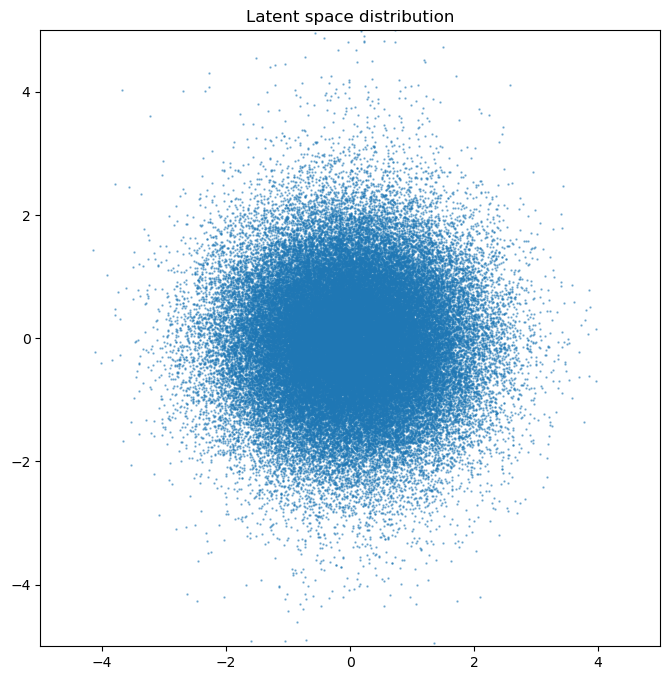

In [19]:
plt.figure(figsize=(8,8))
plt.scatter(z[inds, 0], z[inds, 1], s=0.5, alpha=0.5)
plt.xlim([-5, 5])
plt.ylim([-5, 5])
plt.title('Latent space distribution')